### Open a single grib file to check the contents for the next script, 
The grib files from HRRR-AK keep changing variable names and such, so everytime we download, we have to recheck a single file and adjust the processing script accordingly

created by Cassie Lumbrazo\
last updated: March 2026\
run location: UAS linux\
python environment: **rasterio**

In [1]:
# import packages 
%matplotlib inline

# plotting packages 
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns 

sns.set_theme()
# plt.rcParams['figure.figsize'] = [12,6] #overriding size

# data packages 
import pandas as pd
import numpy as np
import xarray as xr
from datetime import datetime

import scipy

from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap
from matplotlib import ticker

import rioxarray
import rasterio 
import cfgrib
import os

In [2]:
pwd

'/home/cassie/python/repos/snow_model_forcing/icefield_domain'

In [3]:
# adding this for parallel processing
from concurrent.futures import ProcessPoolExecutor

### Open a single grib file to see the current file structure, it keeps changing\
then fix up the variables if needed.

This will print everything going on, open in a text editor and look

In [4]:
import pygrib
import pandas as pd

grib_file = "/hdd/snow_hydrology/hrrrak/icefield_domain/f567/WY2024/hrrr.20231001/hrrr.t00z.wrfsfcf05.ak.grib2"

# Inspect a single GRIB file and summarize variable structure
rows = []
with pygrib.open(grib_file) as grbs:
    print(f"Inspecting: {grib_file}")
    print(f"Total GRIB messages: {grbs.messages}")

    for idx, grb in enumerate(grbs, start=1):
        rows.append(
            {
                "msg": idx,
                "name": grb.name,
                "shortName": getattr(grb, "shortName", ""),
                "typeOfLevel": getattr(grb, "typeOfLevel", ""),
                "level": getattr(grb, "level", None),
                "units": getattr(grb, "units", ""),
                "stepType": getattr(grb, "stepType", ""),
            }
        )

df = pd.DataFrame(rows)

print("\nUnique variables (shortName, typeOfLevel, level):")
print(
    df[["shortName", "name", "typeOfLevel", "level", "units"]]
    .drop_duplicates()
    .sort_values(["shortName", "typeOfLevel", "level"])
    .to_string(index=False)
)

# Focused check for temperature / relative humidity at 2m and 10m
shortname_candidates = ["2t", "2r", "t", "r", "r2", "rh"]
focus = df[
    (
        df["shortName"].str.lower().isin(shortname_candidates)
        | df["name"].str.contains("temperature|relative humidity", case=False, na=False)
    )
    & (df["typeOfLevel"].isin(["heightAboveGround", "surface"]))
]

print("\nTemperature / RH candidates at surface or heightAboveGround:")
if focus.empty:
    print("No temperature/RH candidates found with current filters.")
else:
    print(
        focus[["msg", "shortName", "name", "typeOfLevel", "level", "units"]]
        .drop_duplicates()
        .sort_values(["shortName", "typeOfLevel", "level", "msg"])
        .to_string(index=False)
    )

# Exact 2 m and 10 m diagnostic
hgt = df[df["typeOfLevel"] == "heightAboveGround"].copy()
check_2m_10m = hgt[hgt["level"].isin([2, 10])]

print("\nheightAboveGround messages at 2 m and 10 m:")
if check_2m_10m.empty:
    print("No heightAboveGround messages found at 2 m or 10 m.")
else:
    print(
        check_2m_10m[["msg", "shortName", "name", "level", "units"]]
        .drop_duplicates()
        .sort_values(["level", "shortName", "msg"])
        .to_string(index=False)
    )

Inspecting: /hdd/snow_hydrology/hrrrak/icefield_domain/f567/WY2024/hrrr.20231001/hrrr.t00z.wrfsfcf05.ak.grib2
Total GRIB messages: 171

Unique variables (shortName, typeOfLevel, level):
shortName                                                    name                 typeOfLevel  level              units
      10u                               10 metre U wind component           heightAboveGround     10            m s**-1
      10v                               10 metre V wind component           heightAboveGround     10            m s**-1
       2d                            2 metre dewpoint temperature           heightAboveGround      2                  K
       2r                               2 metre relative humidity           heightAboveGround      2                  %
      2sh                               2 metre specific humidity           heightAboveGround      2          kg kg**-1
       2t                                     2 metre temperature           heightAboveGround 

### Now, this code processes that grib file, 
and will be used to make the next script for processing all the variables 

In [5]:
import xarray as xr
import numpy as np
import pygrib
import os

# Path to a single GRIB file
grib_file = '/hdd/snow_hydrology/hrrrak/icefield_domain/f567/WY2024/hrrr.20231001/hrrr.t00z.wrfsfcf05.ak.grib2'

# List of desired variables (short names from GRIB output, keeping naming conventions)
desired_vars = [
    't',        # Temperature (only surface level now)
    'sp',       # Surface pressure
    '2t',       # 2 metre temperature
    '2r',       # 2 metre relative humidity
    'tp',       # Total Precipitation
    'prate',    # Precipitation rate
    '10u',      # 10 metre U wind component
    '10v',      # 10 metre V wind component
    'sdswrf',   # Surface downward short-wave radiation flux
    'sdlwrf',   # Surface downward long-wave radiation flux
    # Extras
    'gust',     # Wind speed (gust)
    'tcc',      # Total Cloud Cover
    'lcc',      # Low cloud cover
    'mcc',      # Medium cloud cover
    'hcc',      # High cloud cover
    'lai',      # Leaf Area Index
    '2d',       # 2 metre dewpoint temperature
    '2sh',      # 2 metre specific humidity
    'suswrf',   # Surface upward short-wave radiation flux
    'sulwrf',   # Surface upward long-wave radiation flux
    'orog',     # Orography
    'sdwe',     # Water equivalent of accumulated snow depth
    'sde',      # Snow depth
    'veg',      # Vegetation
    'vgtyp',    # Vegetation Type
    'gflux',    # Ground heat flux
]

# Function to open GRIB file and collect desired variables
def collect_desired_vars(file_path, desired_vars):
    grbs = pygrib.open(file_path)
    var_info = {}

    for grb in grbs:
        short_name = grb.shortName.lower()
        if short_name in desired_vars:
            # Special filter: for 't', only keep surface level
            if short_name == 't' and not (grb.typeOfLevel == 'surface'):
                continue

            key = f"{short_name}_{grb.level}_{grb.typeOfLevel}"  # Unique key
            var_info[key] = {
                'short_name': short_name,
                'level': grb.level,
                'typeOfLevel': grb.typeOfLevel,
                'data': grb.values,
                'lat': grb.latlons()[0],
                'lon': grb.latlons()[1],
                # Preserve metadata for downstream labels/plotting
                'name': getattr(grb, 'name', short_name),
                'units': getattr(grb, 'units', ''),
                'cfVarName': getattr(grb, 'cfVarName', ''),
                'paramId': getattr(grb, 'paramId', None),
                'stepType': getattr(grb, 'stepType', ''),
            }

    grbs.close()
    return var_info


# Function to create merged xarray Dataset
def create_merged_dataset(var_info):
    datasets = []

    # Get common lat/lon from first var
    first_key = list(var_info.keys())[0]
    lat = var_info[first_key]['lat']
    lon = var_info[first_key]['lon']

    # Group vars by short_name AND typeOfLevel for proper handling
    grouped_vars = {}
    for key, info in var_info.items():
        group_key = f"{info['short_name']}_{info['typeOfLevel']}"
        if group_key not in grouped_vars:
            grouped_vars[group_key] = []
        grouped_vars[group_key].append(info)

    for group_key, infos in grouped_vars.items():
        short_name = infos[0]['short_name']
        type_level = infos[0]['typeOfLevel']

        if len(infos) == 1:
            # Single level var
            info = infos[0]
            data = info['data']
            level = info['level']

            da_attrs = {
                'long_name': info.get('name', short_name),
                'units': info.get('units', ''),
                'standard_name': info.get('cfVarName', ''),
                'GRIB_shortName': short_name,
                'GRIB_typeOfLevel': type_level,
                'GRIB_level': level,
                'GRIB_paramId': info.get('paramId', None),
                'GRIB_stepType': info.get('stepType', ''),
            }

            if type_level == 'surface' or (type_level == 'heightAboveGround' and level == 0):
                da = xr.DataArray(
                    data,
                    dims=['y', 'x'],
                    coords={
                        'y': range(data.shape[0]),
                        'x': range(data.shape[1]),
                        'latitude': (['y', 'x'], lat),
                        'longitude': (['y', 'x'], lon),
                    },
                    attrs=da_attrs,
                    name=short_name,
                )
            elif type_level == 'heightAboveGround' and level in [2, 10]:
                da = xr.DataArray(
                    data,
                    dims=['y', 'x'],
                    coords={
                        'y': range(data.shape[0]),
                        'x': range(data.shape[1]),
                        'latitude': (['y', 'x'], lat),
                        'longitude': (['y', 'x'], lon),
                    },
                    attrs=da_attrs,
                    name=short_name,
                )
            else:
                da = xr.DataArray(
                    data,
                    dims=['y', 'x'],
                    coords={
                        'y': range(data.shape[0]),
                        'x': range(data.shape[1]),
                        'latitude': (['y', 'x'], lat),
                        'longitude': (['y', 'x'], lon),
                    },
                    attrs=da_attrs,
                    name=short_name,
                )

            datasets.append(da)

        else:
            # Multi-level var (same typeOfLevel, different levels)
            levels = [info['level'] for info in infos]
            data_stack = np.stack([info['data'] for info in infos], axis=0)

            base_attrs = {
                'long_name': infos[0].get('name', short_name),
                'units': infos[0].get('units', ''),
                'standard_name': infos[0].get('cfVarName', ''),
                'GRIB_shortName': short_name,
                'GRIB_typeOfLevel': type_level,
                'GRIB_levels': levels,
                'GRIB_paramId': infos[0].get('paramId', None),
                'GRIB_stepType': infos[0].get('stepType', ''),
            }

            if type_level == 'isobaricInhPa':
                da = xr.DataArray(
                    data_stack,
                    dims=['isobaricInhPa', 'y', 'x'],
                    coords={
                        'isobaricInhPa': levels,
                        'y': range(data_stack.shape[1]),
                        'x': range(data_stack.shape[2]),
                        'latitude': (['y', 'x'], lat),
                        'longitude': (['y', 'x'], lon),
                    },
                    attrs=base_attrs,
                    name=short_name,
                )
            elif type_level == 'heightAboveGround':
                da = xr.DataArray(
                    data_stack,
                    dims=['heightAboveGround', 'y', 'x'],
                    coords={
                        'heightAboveGround': levels,
                        'y': range(data_stack.shape[1]),
                        'x': range(data_stack.shape[2]),
                        'latitude': (['y', 'x'], lat),
                        'longitude': (['y', 'x'], lon),
                    },
                    attrs=base_attrs,
                    name=short_name,
                )
            else:
                # Fallback for other multi-level (e.g., tcc with different layers)
                da = xr.DataArray(
                    data_stack,
                    dims=['level', 'y', 'x'],
                    coords={
                        'level': levels,
                        'y': range(data_stack.shape[1]),
                        'x': range(data_stack.shape[2]),
                        'latitude': (['y', 'x'], lat),
                        'longitude': (['y', 'x'], lon),
                    },
                    attrs=base_attrs,
                    name=short_name,
                )

            datasets.append(da)

    # Merge all DataArrays into a single Dataset, allowing coord overrides
    merged_ds = xr.merge(datasets, compat='override')
    return merged_ds


# Collect vars
var_info = collect_desired_vars(grib_file, desired_vars)

if not var_info:
    print("No desired variables found.")
else:
    # Create merged dataset
    merged_ds = create_merged_dataset(var_info)
    print(merged_ds)

    # # Save to NetCDF
    # output_nc = '/path/to/output/merged_vars.nc'  # Replace with desired output path
    # merged_ds.to_netcdf(output_nc)
    # print(f"Saved merged dataset to {output_nc}")

<xarray.Dataset> Size: 403kB
Dimensions:    (y: 58, x: 31)
Coordinates:
  * y          (y) int64 464B 0 1 2 3 4 5 6 7 8 9 ... 49 50 51 52 53 54 55 56 57
  * x          (x) int64 248B 0 1 2 3 4 5 6 7 8 9 ... 22 23 24 25 26 27 28 29 30
    latitude   (y, x) float64 14kB 58.16 58.16 58.16 58.16 ... 59.68 59.68 59.68
    longitude  (y, x) float64 14kB -135.0 -135.0 -134.9 ... -133.5 -133.5 -133.4
Data variables: (12/26)
    gust       (y, x) float64 14kB 12.53 10.53 8.776 7.526 ... 10.84 9.151 6.964
    sp         (y, x) float64 14kB 1.014e+05 1.014e+05 ... 8.276e+04 8.474e+04
    orog       (y, x) float64 14kB -0.01151 -0.01151 ... 1.644e+03 1.456e+03
    t          (y, x) float64 14kB 282.7 282.7 282.7 282.7 ... 272.8 271.0 271.6
    sdwe       (y, x) float64 14kB 0.0 0.0 0.0 0.0 ... 0.0 0.0146 0.0106 0.0024
    sde        (y, x) float64 14kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.018 0.047
    ...         ...
    mcc        (y, x) float64 14kB 100.0 100.0 100.0 100.0 ... 100.0 100.0 100.0
  

In [6]:
merged_ds

<xarray.Dataset> Size: 403kB
Dimensions:    (y: 58, x: 31)
Coordinates:
  * y          (y) int64 464B 0 1 2 3 4 5 6 7 8 9 ... 49 50 51 52 53 54 55 56 57
  * x          (x) int64 248B 0 1 2 3 4 5 6 7 8 9 ... 22 23 24 25 26 27 28 29 30
    latitude   (y, x) float64 14kB 58.16 58.16 58.16 58.16 ... 59.68 59.68 59.68
    longitude  (y, x) float64 14kB -135.0 -135.0 -134.9 ... -133.5 -133.5 -133.4
Data variables: (12/26)
    gust       (y, x) float64 14kB 12.53 10.53 8.776 7.526 ... 10.84 9.151 6.964
    sp         (y, x) float64 14kB 1.014e+05 1.014e+05 ... 8.276e+04 8.474e+04
    orog       (y, x) float64 14kB -0.01151 -0.01151 ... 1.644e+03 1.456e+03
    t          (y, x) float64 14kB 282.7 282.7 282.7 282.7 ... 272.8 271.0 271.6
    sdwe       (y, x) float64 14kB 0.0 0.0 0.0 0.0 ... 0.0 0.0146 0.0106 0.0024
    sde        (y, x) float64 14kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.018 0.047
    ...         ...
    mcc        (y, x) float64 14kB 100.0 100.0 100.0 100.0 ... 100.0 100.0 100.0
    hcc        (y, x) float64 14kB 100.0 100.0 100.0 100.0 ... 100.0 100.0 100.0
    sdswrf     (y, x) float64 14kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
    sdlwrf     (y, x) float64 14kB 339.1 340.0 340.3 338.5 ... 286.8 303.2 293.5
    suswrf     (y, x) float64 14kB 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
    sulwrf     (y, x) float64 14kB 354.9 354.8 354.8 354.9 ... 292.1 299.6 302.4
Attributes:
    long_name:         Wind speed (gust)
    units:             m s**-1
    standard_name:     gust
    GRIB_shortName:    gust
    GRIB_typeOfLevel:  surface
    GRIB_level:        0
    GRIB_paramId:      260065
    GRIB_stepType:     instant

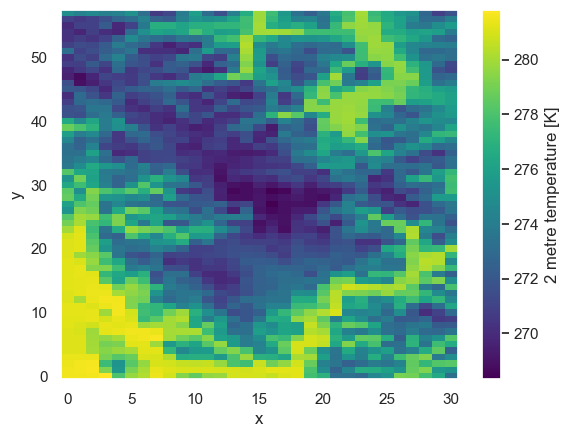

In [7]:
merged_ds['2t'].plot()

/tmp/ipykernel_1006108/2158894437.py:37: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  mesh = plt.pcolormesh(x2d, y2d, field2d, shading="auto", cmap="coolwarm")


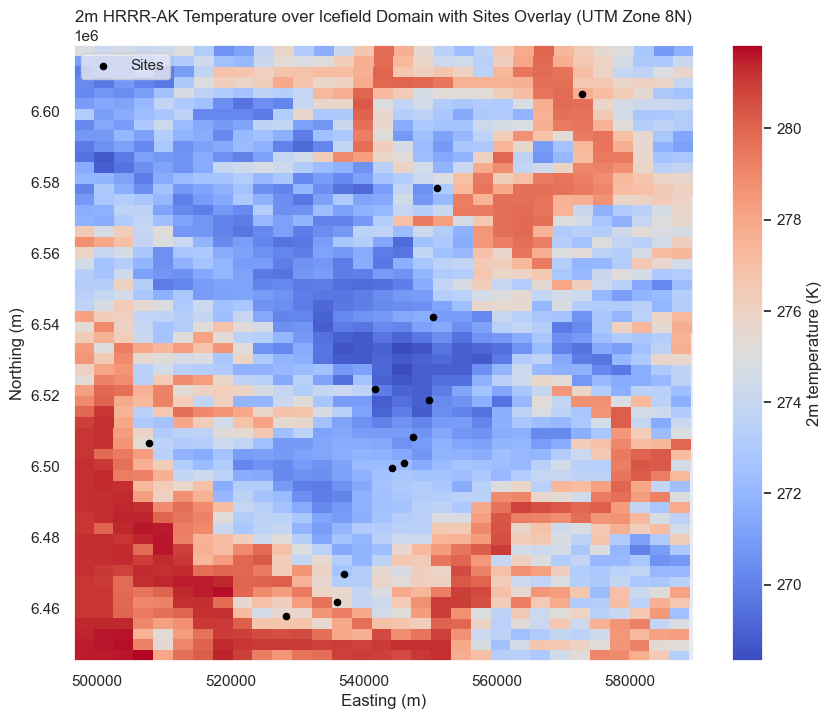

In [8]:
sites_all = pd.DataFrame({
    "lat": [
        58.262, 58.2971, 58.7, 58.63447,   # main
        59.57564, 58.64721, 58.36737, 59.01664,
        58.712433, 59.34211, 58.83497, 58.8067  # icefield
    ],
    "lon": [
        -134.517, -134.386, -134.8667, -134.23708,
        -133.70982, -134.20635, -134.36638, -134.12104,
        -134.182217, -134.10221, -134.27643, -134.13613
    ]
})

# Plot in UTM: convert both raster lon/lat grid and site lon/lat to EPSG:32608
from pyproj import Transformer

da = merged_ds["2t"]

# Reduce to a 2D field for plotting if extra dims exist
if "time" in da.dims:
    da = da.isel(time=0)
if "level" in da.dims:
    da = da.isel(level=0)
if "heightAboveGround" in da.dims:
    da = da.isel(heightAboveGround=0)

lon2d = da["longitude"].values
lat2d = da["latitude"].values
field2d = da.values

# UTM Zone 8N is appropriate for this SE Alaska domain
transformer = Transformer.from_crs("EPSG:4326", "EPSG:32608", always_xy=True)
x2d, y2d = transformer.transform(lon2d, lat2d)
site_x, site_y = transformer.transform(sites_all["lon"].values, sites_all["lat"].values)

plt.figure(figsize=(10, 8))
mesh = plt.pcolormesh(x2d, y2d, field2d, shading="auto", cmap="coolwarm")
plt.colorbar(mesh, label="2m temperature (K)")

plt.scatter(site_x, site_y, color="black", marker="o", s=20, label="Sites")

plt.title("2m HRRR-AK Temperature over Icefield Domain with Sites Overlay (UTM Zone 8N)")
plt.xlabel("Easting (m)")
plt.ylabel("Northing (m)")
plt.legend(loc="upper left")
plt.grid(True, alpha=0.3)
plt.show()

/tmp/ipykernel_1006108/2967698300.py:55: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  mesh = ax.pcolormesh(x2d, y2d, field2d, shading="auto", cmap="viridis")


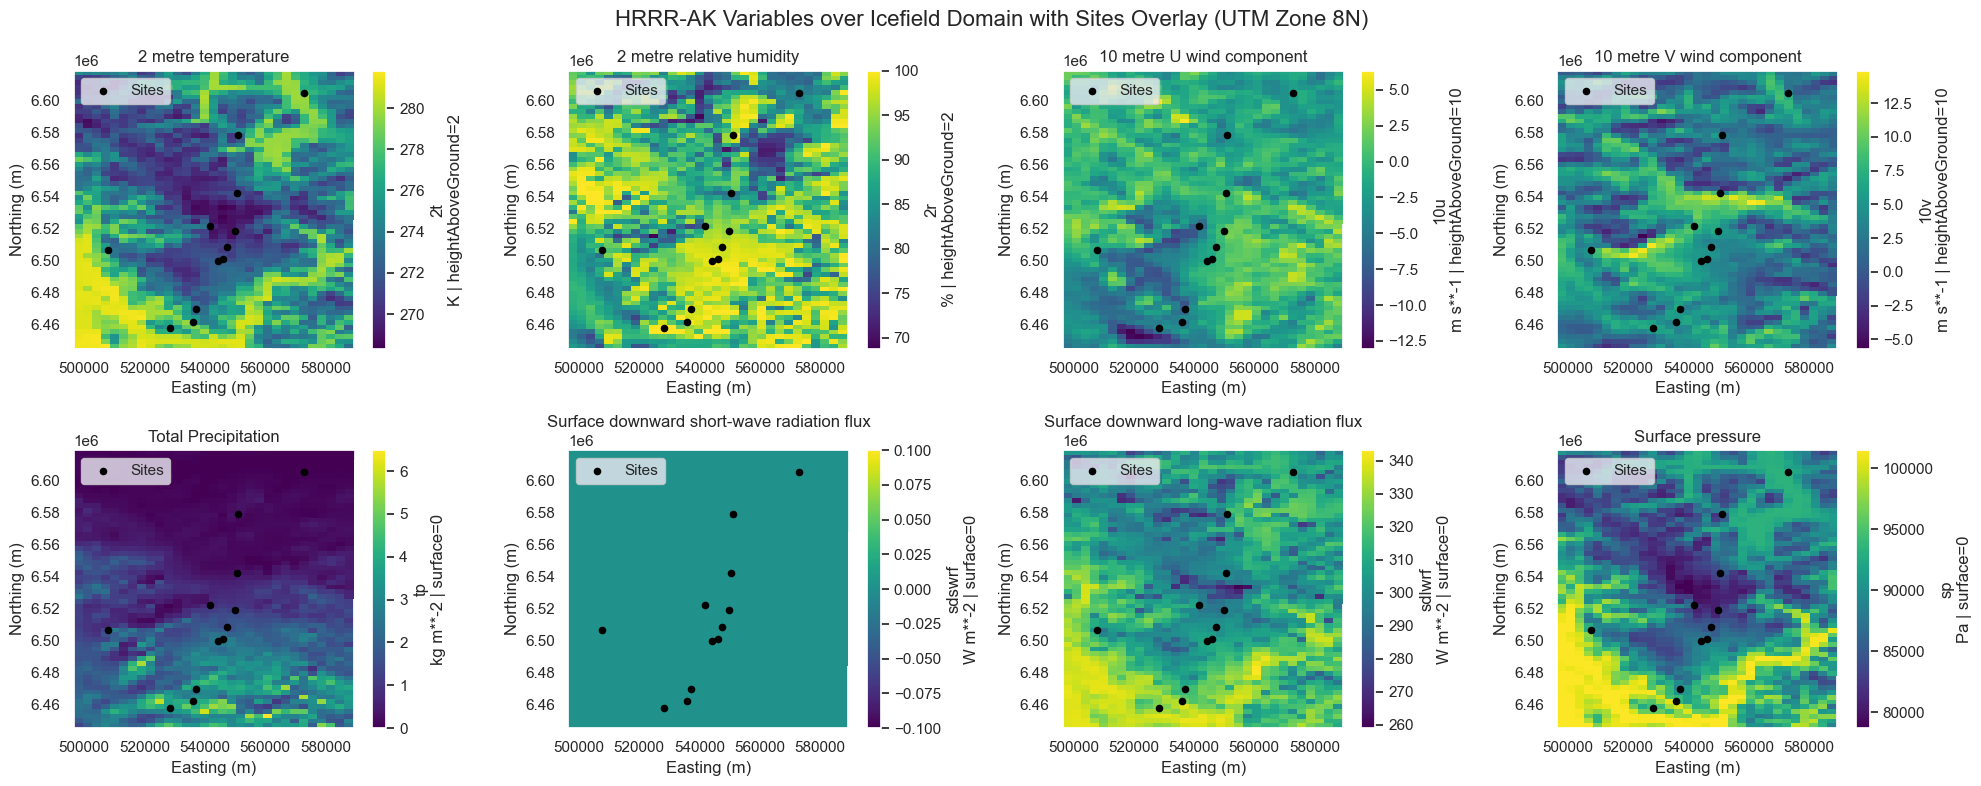

In [12]:
# Multi-variable subplot in UTM Zone 8N (same CRS workflow as single-variable plot)
from pyproj import Transformer

variables_to_plot = ["2t", "2r", "10u", "10v", "tp", "sdswrf", "sdlwrf", "sp"]
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()

# Convert sites once (lon/lat -> UTM)
transformer = Transformer.from_crs("EPSG:4326", "EPSG:32608", always_xy=True)
site_x, site_y = transformer.transform(sites_all["lon"].values, sites_all["lat"].values)

for i, var in enumerate(variables_to_plot):
    if var not in merged_ds:
        print(f"Variable {var} not found in dataset, skipping.")
        axes[i].axis("off")
        continue

    da = merged_ds[var]

    # Use descriptive metadata for labels
    long_name = da.attrs.get("long_name") or da.attrs.get("GRIB_name") or da.attrs.get("standard_name") or var
    units = da.attrs.get("units") or da.attrs.get("GRIB_units") or ""
    level_type = da.attrs.get("GRIB_typeOfLevel")
    level_val = da.attrs.get("GRIB_level")

    level_text = ""
    if level_type is not None and level_val is not None:
        level_text = f"{level_type}={level_val}"

    # Colorbar label: line 1 = variable, line 2 = units + level info
    line2_parts = []
    if units:
        line2_parts.append(units)
    if level_text:
        line2_parts.append(level_text)
    line2 = " | ".join(line2_parts) if line2_parts else "metadata unavailable"
    cbar_label = f"{var}\n{line2}"

    # Reduce to 2D if extra dims exist
    if "time" in da.dims:
        da = da.isel(time=0)
    if "level" in da.dims:
        da = da.isel(level=0)
    if "heightAboveGround" in da.dims:
        da = da.isel(heightAboveGround=0)

    lon2d = da["longitude"].values
    lat2d = da["latitude"].values
    field2d = da.values

    # Convert raster grid lon/lat to UTM
    x2d, y2d = transformer.transform(lon2d, lat2d)

    ax = axes[i]
    mesh = ax.pcolormesh(x2d, y2d, field2d, shading="auto", cmap="viridis")
    fig.colorbar(mesh, ax=ax, label=cbar_label)

    # Overlay sites in same CRS
    ax.scatter(site_x, site_y, color="black", marker="o", s=20, label="Sites")

    ax.set_title(f"{long_name}")
    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")
    ax.legend(loc="upper left")
    ax.grid(True, alpha=0.3)

# Hide any unused subplot axes
for j in range(len(variables_to_plot), len(axes)):
    axes[j].axis("off")

plt.suptitle("HRRR-AK Variables over Icefield Domain with Sites Overlay (UTM Zone 8N)", fontsize=16)
plt.tight_layout()
plt.show()